In [14]:
import gym
import numpy as np

In [12]:
env = gym.make('FrozenLake-v1')
States = env.observation_space.n
Actions = env.action_space.n

In [15]:
Q = np.zeros((States, Actions))

In [16]:
Episodes = 1500
Max_steps = 100
Learning_rate = 0.81
Gamma = 0.96
Render = False
epsilon = 0.9

In [30]:
rewards = []
for episode in range(Episodes):
    state = env.reset()
    for _ in range(Max_steps):
        if type(state) is tuple:
            if len(state) == 2:
                state = state[0]
        else:
            state = state
            
        if Render:
            env.render()
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state, :])
        next_state, reward, done, _, _ = env.step(action)
        Q[state, action] = Q[state, action] + Learning_rate * (reward + Gamma * np.max(Q[next_state, :]) - Q[state, action])
        state = next_state
        if done:
            rewards.append(reward)
            epsilon -= 0.001
            break
print(Q)
print(f"Average Reward: {sum(rewards)/len(rewards)}:")

[[8.09706267e-03 1.22565736e-01 6.81296363e-03 8.02643449e-03]
 [4.49539351e-03 2.00326778e-03 2.62141640e-03 6.51672318e-02]
 [3.77094602e-03 3.53021582e-03 2.16922972e-03 3.35128922e-02]
 [2.60357903e-03 9.03313157e-04 9.05170847e-04 2.91250576e-02]
 [2.12633975e-01 3.58413410e-03 2.76565382e-03 2.17015276e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.10972042e-06 1.53426960e-07 2.26235840e-04 1.47681577e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.62072013e-03 3.70690541e-03 2.20526012e-03 3.06905293e-01]
 [4.06853207e-03 4.47471466e-01 4.08862460e-03 4.92626142e-03]
 [4.08272576e-02 3.90716566e-04 1.01237902e-03 1.00127193e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.44899231e-02 4.10791147e-02 5.34019439e-01 4.89586623e-02]
 [1.59201660e-01 9.16838207e-01 1.75168831e-01 6.65061848e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

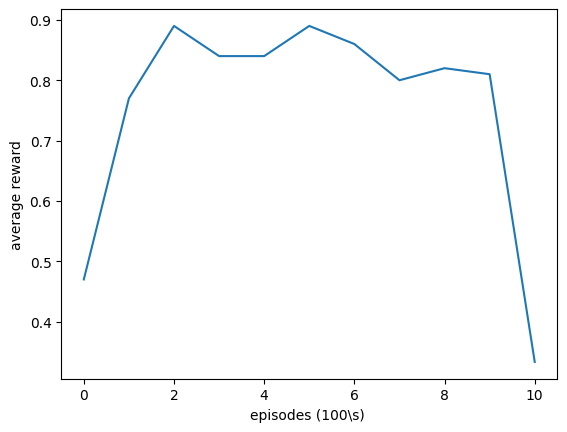

In [31]:
import matplotlib.pyplot as plt
def get_average(values):
    return sum(values)/len(values)
avg_rewards = []
for i in range(0, len(rewards), 100):
    avg_rewards.append(get_average(rewards[i:i+100]))
plt.plot(avg_rewards)
plt.ylabel('average reward')
plt.xlabel('episodes (100\s) ')
plt.show()
